In [3]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import glob
import os
from scipy import signal
from scipy.fft import fft, fftfreq
from scipy.stats import gaussian_kde

In [2]:


# ============================================================
# Configuración de rutas y coordenadas
# ============================================================
ruta_base = "P:/clima/datos/haduk/"
ruta_rain = os.path.join(ruta_base, "rainfall")
ruta_tasmax = os.path.join(ruta_base, "tas/tasmax")
ruta_tasmin = os.path.join(ruta_base, "tas/tasmin")

lon_london, lat_london = -0.1, 51.5
years = range(1986, 1999)  # 1986 a 1998 inclusive

# ============================================================
# Función robusta para procesar variable (maneja coordenadas 2D)
# ============================================================
def procesar_variable(ruta, var_name, coord_lon, coord_lat, years):
    archivos = sorted(glob.glob(os.path.join(ruta, "*.nc")))
    lista_dfs = []
    for archivo in archivos:
        año = int(os.path.basename(archivo).split('_')[-1].split('-')[0][:4])
        if año in years:
            ds = xr.open_dataset(archivo)

            # ---- Encontrar índices (y,x) de la celda más cercana ----
            # Calcular distancia cuadrada en cada punto de la malla
            lat = ds['latitude']      # matriz 2D (y, x)
            lon = ds['longitude']     # matriz 2D (y, x)
            dist_sq = (lat - coord_lat)**2 + (lon - coord_lon)**2

            # Índice plano del mínimo
            idx_flat = np.argmin(dist_sq.data)
            # Convertir a índices 2D (asumiendo orden 'C' por filas)
            ny, nx = dist_sq.shape
            idx_y = idx_flat // nx
            idx_x = idx_flat % nx

            

            # Extraer la serie temporal usando isel con las dimensiones correctas
            punto = ds[var_name].isel(
                projection_y_coordinate=idx_y,
                projection_x_coordinate=idx_x
            ).squeeze()

            # Convertir a DataFrame
            df = punto.to_dataframe().reset_index()
            df['year'] = año
            lista_dfs.append(df)
            ds.close()
    return pd.concat(lista_dfs, ignore_index=True)

# ============================================================
# 1. Cargar datos
# ============================================================

df_rain = procesar_variable(ruta_rain, 'rainfall', lon_london, lat_london, years)

df_tmax = procesar_variable(ruta_tasmax, 'tasmax', lon_london, lat_london, years)

df_tmin = procesar_variable(ruta_tasmin, 'tasmin', lon_london, lat_london, years)

# ============================================================
# 2. Unir y calcular temperatura media
# ============================================================
# Unir tmax y tmin por fecha
df_temp = pd.merge(
    df_tmax[['time', 'tasmax']].rename(columns={'time': 'date', 'tasmax': 'tmax'}),
    df_tmin[['time', 'tasmin']].rename(columns={'time': 'date', 'tasmin': 'tmin'}),
    on='date', how='outer'
)
df_temp['tmean'] = (df_temp['tmax'] + df_temp['tmin']) / 2

# Renombrar precipitación
df_rain = df_rain.rename(columns={'time': 'date', 'rainfall': 'precip'})

# Unir todo en un DataFrame diario
df_daily = pd.merge(df_temp[['date', 'tmean']], df_rain[['date', 'precip']],
                    on='date', how='outer')
df_daily = df_daily.sort_values('date').reset_index(drop=True)

# ============================================================
# 3. Verificar e interpolar valores faltantes
# ============================================================
print("\nValores faltantes antes de interpolación:")
print(df_daily[['tmean', 'precip']].isna().sum())

df_daily['tmean'] = df_daily['tmean'].interpolate(method='linear', limit=5, limit_direction='both')
df_daily['precip'] = df_daily['precip'].interpolate(method='linear', limit=5, limit_direction='both')

# Si aún quedan NaN (huecos >5 días), completar con interpolación total
if df_daily['tmean'].isna().any():
    df_daily['tmean'] = df_daily['tmean'].interpolate(method='linear', limit_direction='both')
if df_daily['precip'].isna().any():
    df_daily['precip'] = df_daily['precip'].interpolate(method='linear', limit_direction='both')

print("\nValores faltantes después de interpolación:")
print(df_daily[['tmean', 'precip']].isna().sum())

# ============================================================
# 4. Crear columnas auxiliares y agregaciones
# ============================================================
df_daily['year'] = df_daily['date'].dt.year
df_daily['month'] = df_daily['date'].dt.month
df_daily['dayofyear'] = df_daily['date'].dt.dayofyear

def get_season(month):
    if month in [12, 1, 2]:
        return 'DJF'
    elif month in [3, 4, 5]:
        return 'MAM'
    elif month in [6, 7, 8]:
        return 'JJA'
    else:
        return 'SON'

df_daily['season'] = df_daily['month'].apply(get_season)

# ---- Mensual ----
monthly = df_daily.groupby(['year', 'month']).agg(
    tmean=('tmean', 'mean'),
    precip=('precip', 'sum')
).reset_index()
monthly['date'] = pd.to_datetime(monthly[['year', 'month']].assign(day=1))

# ---- Anual ----
annual = df_daily.groupby('year').agg(
    tmean=('tmean', 'mean'),
    precip=('precip', 'sum')
).reset_index()
annual['date'] = pd.to_datetime(annual['year'], format='%Y')

# ---- Estacional ----
seasonal = df_daily.groupby(['year', 'season']).agg(
    tmean=('tmean', 'mean'),
    precip=('precip', 'sum')
).reset_index()
season_map = {'DJF': '01', 'MAM': '04', 'JJA': '07', 'SON': '10'}
seasonal['date'] = pd.to_datetime(seasonal['year'].astype(str) + '-' +
                                   seasonal['season'].map(season_map) + '-01')
seasonal = seasonal.sort_values('date').reset_index(drop=True)

# ============================================================
# 5. Calcular climatologías y anomalías
# ============================================================
# ---- Diario ----
clim_daily = df_daily.groupby('dayofyear')['tmean'].mean().reset_index().rename(
    columns={'tmean': 'clim_daily'})
df_daily = df_daily.merge(clim_daily, on='dayofyear')
df_daily['tmean_anom_daily'] = df_daily['tmean'] - df_daily['clim_daily']

clim_daily_pr = df_daily.groupby('dayofyear')['precip'].mean().reset_index().rename(
    columns={'precip': 'clim_daily_pr'})
df_daily = df_daily.merge(clim_daily_pr, on='dayofyear')
df_daily['precip_anom_daily'] = df_daily['precip'] - df_daily['clim_daily_pr']

# ---- Mensual ----
clim_monthly = monthly.groupby('month')['tmean'].mean().reset_index().rename(
    columns={'tmean': 'clim_monthly'})
monthly = monthly.merge(clim_monthly, on='month')
monthly['tmean_anom'] = monthly['tmean'] - monthly['clim_monthly']

clim_monthly_pr = monthly.groupby('month')['precip'].mean().reset_index().rename(
    columns={'precip': 'clim_monthly_pr'})
monthly = monthly.merge(clim_monthly_pr, on='month')
monthly['precip_anom'] = monthly['precip'] - monthly['clim_monthly_pr']

# ---- Anual ----
clim_annual = annual['tmean'].mean()
annual['tmean_anom'] = annual['tmean'] - clim_annual

clim_annual_pr = annual['precip'].mean()
annual['precip_anom'] = annual['precip'] - clim_annual_pr

# ---- Estacional ----
clim_seasonal = seasonal.groupby('season')['tmean'].mean().reset_index().rename(
    columns={'tmean': 'clim_seasonal'})
seasonal = seasonal.merge(clim_seasonal, on='season')
seasonal['tmean_anom'] = seasonal['tmean'] - seasonal['clim_seasonal']

clim_seasonal_pr = seasonal.groupby('season')['precip'].mean().reset_index().rename(
    columns={'precip': 'clim_seasonal_pr'})
seasonal = seasonal.merge(clim_seasonal_pr, on='season')
seasonal['precip_anom'] = seasonal['precip'] - seasonal['clim_seasonal_pr']




Valores faltantes antes de interpolación:
tmean     0
precip    0
dtype: int64

Valores faltantes después de interpolación:
tmean     0
precip    0
dtype: int64


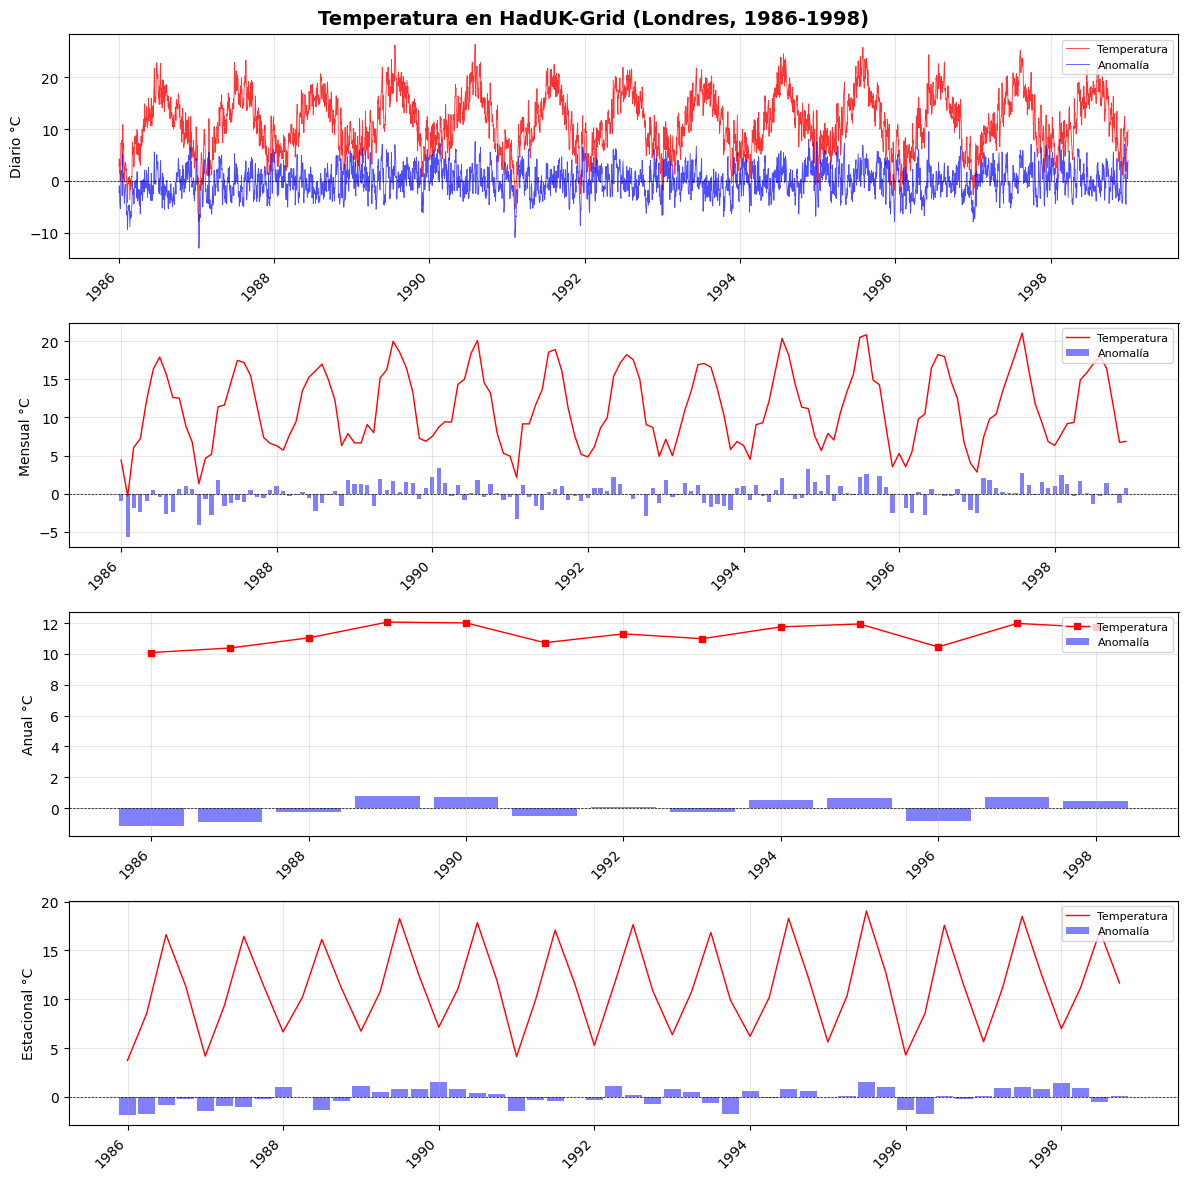

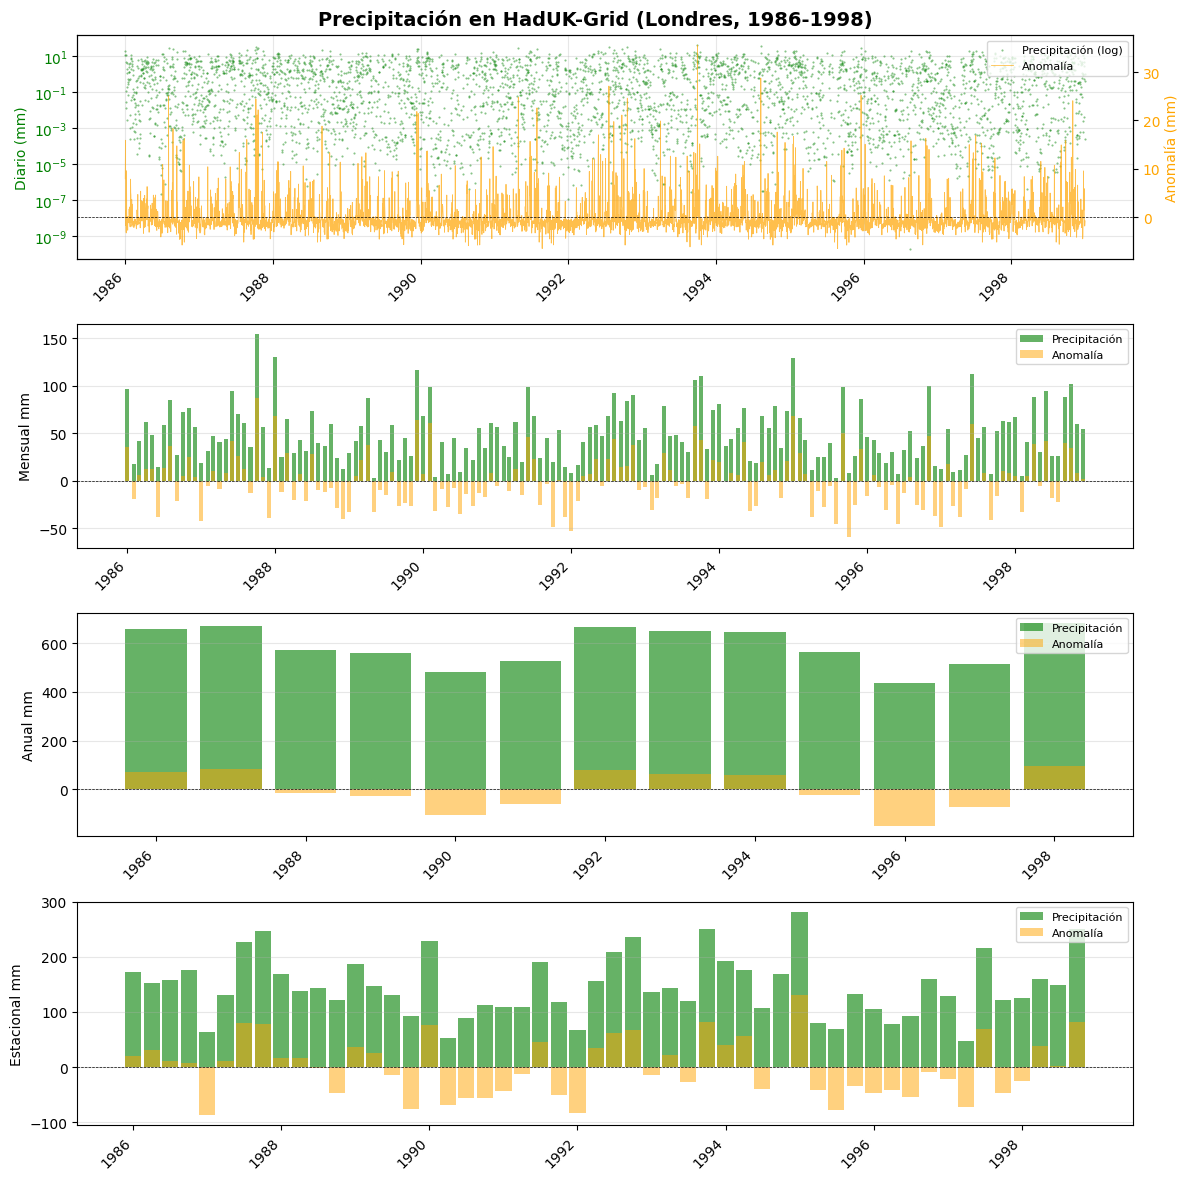

In [4]:
# ============================================================
# 6. Figura 1: Temperatura (4 paneles, cada panel con serie y anomalía)
# ============================================================
fig, axes = plt.subplots(4, 1, figsize=(12, 12))
fig.suptitle('Temperatura en HadUK-Grid (Londres, 1986-1998)', fontsize=14, fontweight='bold')

# Colores
color_temp = 'red'
color_anom = 'blue'

# Panel 1: Diario
ax = axes[0]
ax.plot(df_daily['date'], df_daily['tmean'], color=color_temp, linewidth=0.6, alpha=0.8, label='Temperatura')
ax.plot(df_daily['date'], df_daily['tmean_anom_daily'], color=color_anom, linewidth=0.6, alpha=0.7, label='Anomalía')
ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
ax.set_ylabel('Diario °C')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)

# Panel 2: Mensual
ax = axes[1]
ax.plot(monthly['date'], monthly['tmean'], color=color_temp, linewidth=1, label='Temperatura')
ax.bar(monthly['date'], monthly['tmean_anom'], width=20, color=color_anom, alpha=0.5, label='Anomalía')
ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
ax.set_ylabel('Mensual °C')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)

# Panel 3: Anual
ax = axes[2]
ax.plot(annual['date'], annual['tmean'], color=color_temp, marker='s', markersize=4, linewidth=1, label='Temperatura')
ax.bar(annual['date'], annual['tmean_anom'], width=300, color=color_anom, alpha=0.5, label='Anomalía')
ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
ax.set_ylabel('Anual °C')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)

# Panel 4: Estacional
ax = axes[3]
ax.plot(seasonal['date'], seasonal['tmean'], color=color_temp, linewidth=1, label='Temperatura')
ax.bar(seasonal['date'], seasonal['tmean_anom'], width=80, color=color_anom, alpha=0.5, label='Anomalía')
ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
ax.set_ylabel('Estacional °C')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)

# Formato de fechas común
for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('P:/clima/datos/haduk/temperatura_haduk_1986_1998.png', dpi=300)
plt.show()

# ============================================================
# 7. Figura 2: Precipitación (4 paneles, cada panel con serie y anomalía)
# ============================================================
fig, axes = plt.subplots(4, 1, figsize=(12, 12))
fig.suptitle('Precipitación en HadUK-Grid (Londres, 1986-1998)', fontsize=14, fontweight='bold')

# Colores
color_precip = 'green'
color_anom = 'orange'

# Diario 
ax1 = axes[0]
# Serie en escala logarítmica 
precip_log = df_daily['precip'].replace(0, np.nan)
ax1.semilogy(df_daily['date'], precip_log, color=color_precip, marker='.', markersize=1, linestyle='', alpha=0.5, label='Precipitación (log)')
ax1.set_ylabel('Diario (mm)', color=color_precip)
ax1.tick_params(axis='y', labelcolor=color_precip)
ax1.grid(True, alpha=0.3, which='both')

# Anomalía en eje secundario (escala lineal)
ax1b = ax1.twinx()
ax1b.plot(df_daily['date'], df_daily['precip_anom_daily'], color=color_anom, linewidth=0.6, alpha=0.7, label='Anomalía')
ax1b.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
ax1b.set_ylabel('Anomalía (mm)', color=color_anom)
ax1b.tick_params(axis='y', labelcolor=color_anom)

# Leyenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=8)



#Panel 2: Mensual 
ax2 = axes[1]
ax2.bar(monthly['date'], monthly['precip'], width=20, color=color_precip, alpha=0.6, label='Precipitación')
ax2.bar(monthly['date'], monthly['precip_anom'], width=20, color=color_anom, alpha=0.5, label='Anomalía')
ax2.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
ax2.set_ylabel('Mensual mm')
ax2.legend(loc='upper right', fontsize=8)
ax2.grid(True, alpha=0.3, axis='y')

# Anual
ax3 = axes[2]
ax3.bar(annual['date'], annual['precip'], width=300, color=color_precip, alpha=0.6, label='Precipitación')
ax3.bar(annual['date'], annual['precip_anom'], width=300, color=color_anom, alpha=0.5, label='Anomalía')
ax3.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
ax3.set_ylabel('Anual mm')
ax3.legend(loc='upper right', fontsize=8)
ax3.grid(True, alpha=0.3, axis='y')

# Estacional 
ax4 = axes[3]
ax4.bar(seasonal['date'], seasonal['precip'], width=80, color=color_precip, alpha=0.6, label='Precipitación')
ax4.bar(seasonal['date'], seasonal['precip_anom'], width=80, color=color_anom, alpha=0.5, label='Anomalía')
ax4.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
ax4.set_ylabel('Estacional mm')
ax4.legend(loc='upper right', fontsize=8)
ax4.grid(True, alpha=0.3, axis='y')

# Formato de fechas común para todos los ejes 
for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('P:/clima/datos/haduk/precipitacion_haduk_1986_1998.png', dpi=300)
plt.show()

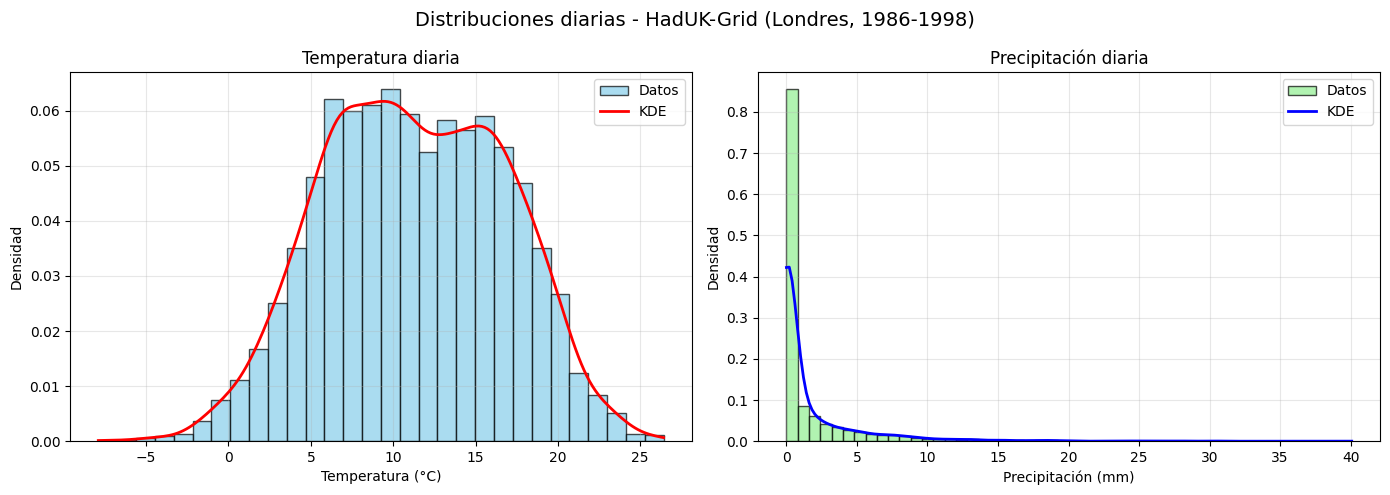

In [5]:


# ============================================================
# Extraer series diarias (ya sin NaN)
# ============================================================
temp_data = df_daily['tmean'].dropna()    # temperatura media diaria
precip_data = df_daily['precip'].dropna() # precipitación diaria

# ============================================================
# Figura con dos paneles: temperatura y precipitación
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribuciones diarias - HadUK-Grid (Londres, 1986-1998)', fontsize=14)

#  Histograma de temperatura ----------
ax = axes[0]
ax.hist(temp_data, bins=30, color='skyblue', edgecolor='black', alpha=0.7, density=True, label='Datos')
# Estimación de densidad kernel (KDE)
kde_temp = gaussian_kde(temp_data)
x_temp = np.linspace(temp_data.min(), temp_data.max(), 200)
ax.plot(x_temp, kde_temp(x_temp), color='red', linewidth=2, label='KDE')
ax.set_xlabel('Temperatura (°C)')
ax.set_ylabel('Densidad')
ax.set_title('Temperatura diaria')
ax.legend()
ax.grid(True, alpha=0.3)

#Histograma de precipitación ----------
ax = axes[1]
ax.hist(precip_data, bins=50, color='lightgreen', edgecolor='black', alpha=0.7, density=True, label='Datos')
kde_precip = gaussian_kde(precip_data)
x_precip = np.linspace(precip_data.min(), precip_data.max(), 200)
ax.plot(x_precip, kde_precip(x_precip), color='blue', linewidth=2, label='KDE')
ax.set_xlabel('Precipitación (mm)')
ax.set_ylabel('Densidad')
ax.set_title('Precipitación diaria')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('haduk_histogramas_diarios.png', dpi=300)
plt.show()



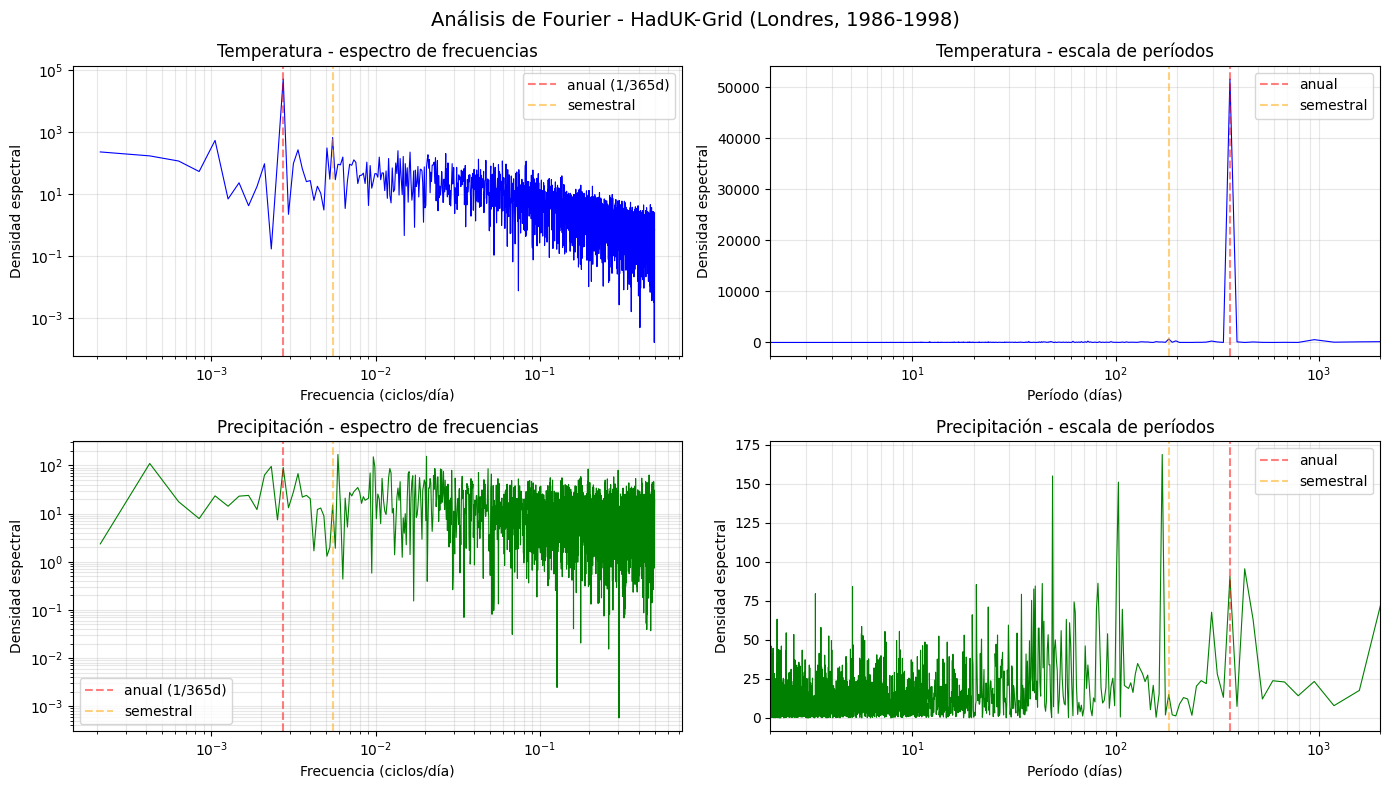

In [6]:

# ============================================================
# PUNTO 7: ANÁLISIS DE FOURIER PARA HADUK-GRID
# ============================================================

# Extraer series diarias (ya están sin NaN por la interpolación)
temp = df_daily['tmean'].values
precip = df_daily['precip'].values
n = len(temp)
dt = 1.0  # días
frecuencias = fftfreq(n, d=dt)[:n//2]
periodos = 1 / frecuencias[1:]  # omitir frecuencia cero

def plot_spectrum(serie, titulo, color, ax_freq=None, ax_per=None):
    # Eliminar tendencia lineal
    serie_detrend = signal.detrend(serie)
    # FFT
    fft_vals = fft(serie_detrend)
    potencia = np.abs(fft_vals[:n//2])**2 / n
    # Frecuencia
    if ax_freq is not None:
        ax_freq.loglog(frecuencias[1:], potencia[1:], color=color, linewidth=0.8)
        ax_freq.set_xlabel('Frecuencia (ciclos/día)')
        ax_freq.set_ylabel('Densidad espectral')
        ax_freq.set_title(titulo + ' - espectro de frecuencias')
        ax_freq.grid(True, alpha=0.3, which='both')
        ax_freq.axvline(1/365.25, color='red', linestyle='--', alpha=0.5, label='anual (1/365d)')
        ax_freq.axvline(2/365.25, color='orange', linestyle='--', alpha=0.5, label='semestral')
        ax_freq.legend()
    # Período
    if ax_per is not None:
        ax_per.semilogx(periodos, potencia[1:], color=color, linewidth=0.8)
        ax_per.set_xlabel('Período (días)')
        ax_per.set_ylabel('Densidad espectral')
        ax_per.set_title(titulo + ' - escala de períodos')
        ax_per.axvline(365.25, color='red', linestyle='--', alpha=0.5, label='anual')
        ax_per.axvline(182.6, color='orange', linestyle='--', alpha=0.5, label='semestral')
        ax_per.set_xlim([2, 2000])
        ax_per.grid(True, alpha=0.3, which='both')
        ax_per.legend()

# Crear figura con 2 filas (temp, precip) y 2 columnas 
fig, ((ax1_freq, ax1_per), (ax2_freq, ax2_per)) = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Análisis de Fourier - HadUK-Grid (Londres, 1986-1998)', fontsize=14)

plot_spectrum(temp, 'Temperatura', 'blue', ax_freq=ax1_freq, ax_per=ax1_per)
plot_spectrum(precip, 'Precipitación', 'green', ax_freq=ax2_freq, ax_per=ax2_per)

plt.tight_layout()
plt.savefig('haduk_fourier_completo.png', dpi=300)
plt.show()